In [3]:
import os
import pandas as pd
path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)

c:\Universidad\1\Universidad\TFG\TFG


In [14]:
df_1 = pd.read_excel(path+'/transcripts/Discourse-UWO/metadata.xlsx',index_col=0, sheet_name= "Data-12m")

In [15]:
metadata = pd.read_excel(path+'/transcripts/Discourse-UWO/metadata.xlsx',index_col=0)

In [16]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})
import seaborn as sns

## Age Analysis

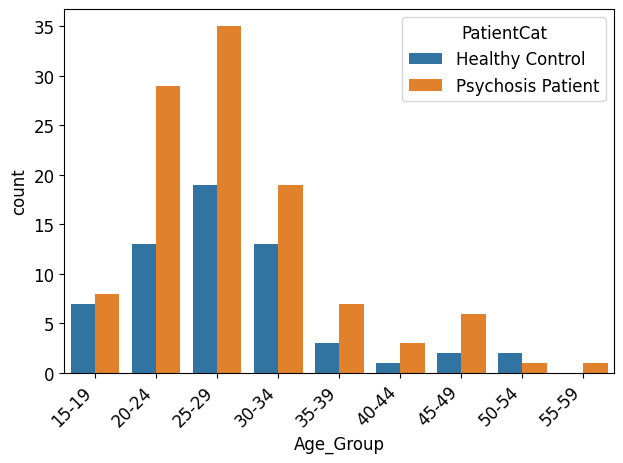

In [17]:
labels = [f"{i}-{i+4}" for i in range(0, 100, 5)]
metadata['Age_Group'] = pd.cut(metadata['Age_years'], bins=range(0, 101, 5), right=False, labels=labels)
metadata['Age_Group'] = pd.Categorical(metadata['Age_Group'], categories=labels, ordered=True)

# Mapear los valores de PatientCat
metadata['PatientCat'] = metadata['PatientCat'].map({1: "Healthy Control", 2: "Psychosis Patient"})

valid_groups = metadata['Age_Group'].dropna().unique()
valid_groups = sorted(valid_groups, key=lambda x: labels.index(x))

grafica = sns.countplot(x="Age_Group", hue='PatientCat', data=metadata, order=valid_groups)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Descriptive Statistics for Age_years and PatientCat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
 
# Summary statistics for Age_years
age_summary = metadata['Age_years'].describe()
print("Summary Statistics for Age_years:")
print(age_summary)

age_summary_pt = metadata[metadata['PatientCat']=="Psychosis Patient"]['Age_years'].describe()
print("Summary Statistics for Age_years Psychosis:")
print(age_summary_pt)

age_summary_hc = metadata[metadata['PatientCat']=="Healthy Control"]['Age_years'].describe()
print("Summary Statistics for Age_years Healthy:")
print(age_summary_hc)

Summary Statistics for Age_years:
count    169.000000
mean      28.461538
std        7.649307
min       18.000000
25%       23.000000
50%       27.000000
75%       30.000000
max       57.000000
Name: Age_years, dtype: float64
Summary Statistics for Age_years Psychosis:
count    109.000000
mean      28.587156
std        7.592895
min       18.000000
25%       24.000000
50%       27.000000
75%       31.000000
max       57.000000
Name: Age_years, dtype: float64
Summary Statistics for Age_years Healthy:
count    60.000000
mean     28.233333
std       7.809960
min      19.000000
25%      23.000000
50%      28.000000
75%      30.000000
max      53.000000
Name: Age_years, dtype: float64


## Gender Analysis

All patients distribution: Gender
Male      121
Female     48
Name: count, dtype: int64


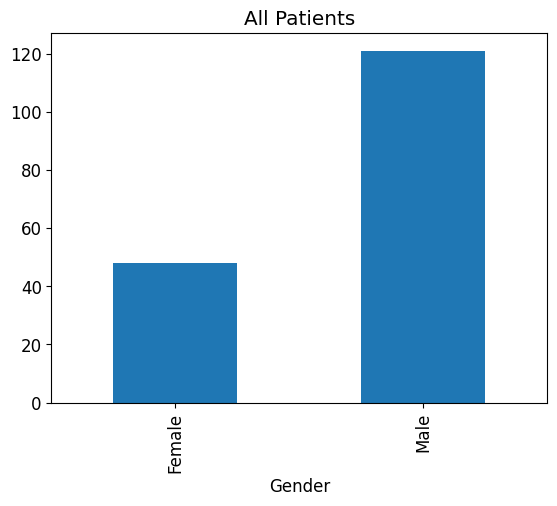

Psychosis patietns distribution:Gender
Male      83
Female    26
Name: count, dtype: int64


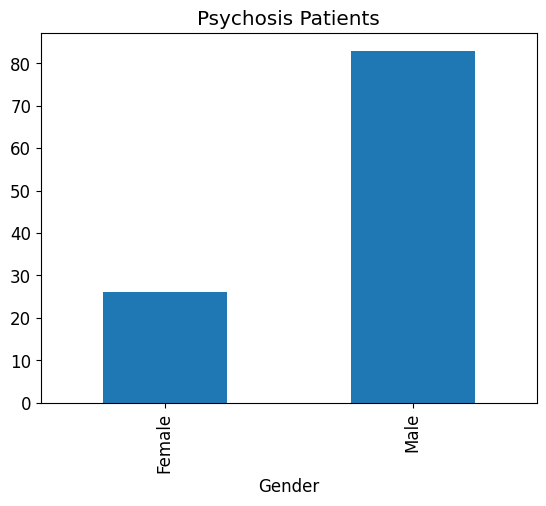

Healthy controls distribution:Gender
Male      38
Female    22
Name: count, dtype: int64


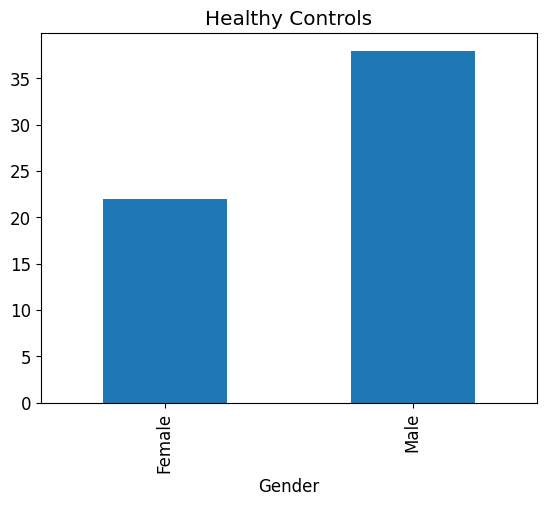

In [19]:
# Descriptive Statistics for Age_years and PatientCat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
gender = {1:"Female",2:"Male"}
 
# Summary statistics for Age_years
plt.title("All Patients")
print(f"All patients distribution: {metadata['Gender'].apply(lambda x:gender[x]).value_counts()}")
age_summary = metadata['Gender'].apply(lambda x:gender[x]).value_counts().reindex(['Female', 'Male']).plot(kind='bar')
plt.show()
plt.title("Psychosis Patients")
print(f"Psychosis patietns distribution:{metadata[metadata['PatientCat']=="Psychosis Patient"]['Gender'].apply(lambda x:gender[x]).value_counts()}")
metadata[metadata['PatientCat']=="Psychosis Patient"]['Gender'].apply(lambda x:gender[x]).value_counts().reindex(['Female', 'Male']).plot(kind='bar')
plt.show()
plt.title("Healthy Controls")
print(f"Healthy controls distribution:{metadata[metadata['PatientCat']=="Healthy Control"]['Gender'].apply(lambda x:gender[x]).value_counts()}")
age_summary_hc = metadata[metadata['PatientCat']=="Healthy Control"]['Gender'].apply(lambda x:gender[x]).value_counts().reindex(['Female', 'Male']).plot(kind='bar')
plt.show()


## Transcription Analysis

In [20]:
df_healthy = pd.read_json('../../data/ordered_healthy_train_dataset.json',lines=True)
df_patient = pd.read_json('../../data/ordered_PT_train_dataset.json',lines=True)

In [21]:
healthy_answer = df_healthy['answer'].str.len()
patient_answer = df_patient['answer'].str.len()
healthy_question = df_healthy['question'].str.len()
patient_question = df_patient['question'].str.len()

print("Summary statistics for answer length: Healthy Control group")
print(healthy_answer.describe())
print("Summary statistics for answer length: Psychosis Patient group")
print(patient_answer.describe())
print("Summary statistics for question length: Healthy Control group")
print(healthy_question.describe())
print("Summary statistics for question length: Psychosis Patient group")
print(patient_question.describe())

Summary statistics for answer length: Healthy Control group
count    2756.000000
mean      279.872279
std       403.845549
min         3.000000
25%        16.000000
50%        87.000000
75%       420.000000
max      3330.000000
Name: answer, dtype: float64
Summary statistics for answer length: Psychosis Patient group
count    7078.000000
mean      162.983470
std       288.223015
min         3.000000
25%        14.000000
50%        56.000000
75%       194.750000
max      9035.000000
Name: answer, dtype: float64
Summary statistics for question length: Healthy Control group
count    2756.000000
mean       81.109579
std        91.331352
min         3.000000
25%        13.000000
50%        50.000000
75%       110.000000
max       595.000000
Name: question, dtype: float64
Summary statistics for question length: Psychosis Patient group
count    7078.000000
mean       69.787934
std        80.512507
min         3.000000
25%        11.000000
50%        45.000000
75%        93.000000
max       70

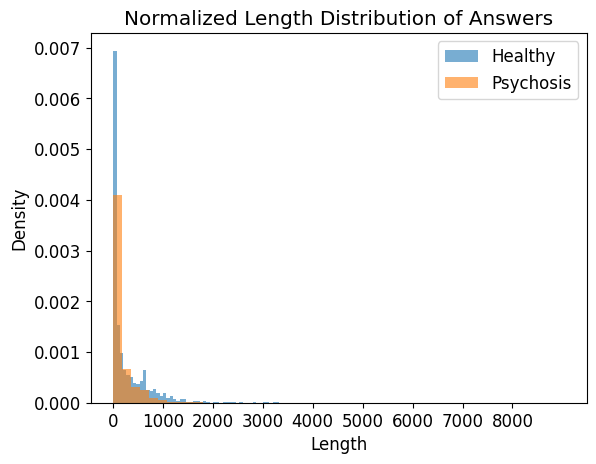

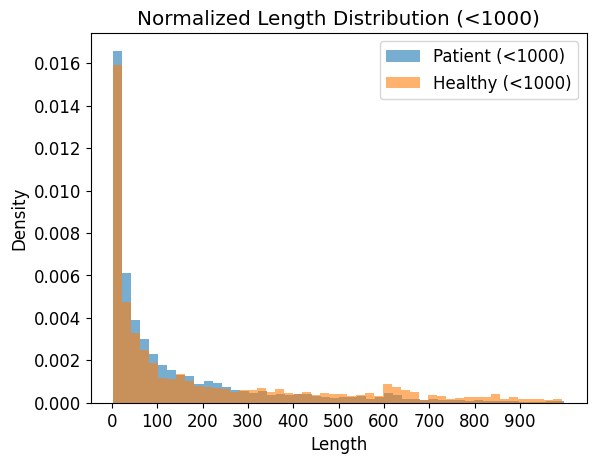

In [22]:
df_healthy['answer'].str.len().plot(kind="hist",bins=50,label="Healthy",alpha=0.6,density=True)
df_patient['answer'].str.len().plot(kind="hist",bins=50,label="Psychosis",alpha=0.6,density=True)
plt.title("Normalized Length Distribution of Answers")
plt.xlabel("Length")
plt.ylabel("Density")
plt.xticks(range(0, 8001, 1000))
plt.legend()
plt.show()

healthy_short = df_healthy[df_healthy['answer'].str.len() < 1000]['answer'].str.len()
patient_short = df_patient[df_patient['answer'].str.len() < 1000]['answer'].str.len()
patient_short.plot(kind="hist", bins=50, alpha=0.6, density=True, label="Patient (<1000)")
healthy_short.plot(kind="hist", bins=50, alpha=0.6, density=True, label="Healthy (<1000)")

plt.title("Normalized Length Distribution (<1000)")
plt.xlabel("Length")
plt.ylabel("Density")
plt.xticks(range(0, 1000, 100))
plt.legend()
plt.show()

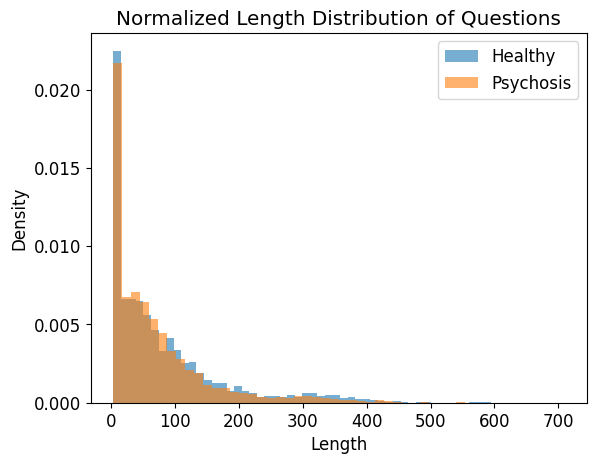

In [23]:
df_healthy['question'].str.len().plot(kind="hist",bins=50,label="Healthy",alpha=0.6,density=True)
df_patient['question'].str.len().plot(kind="hist",bins=50,label="Psychosis",alpha=0.6,density=True)
plt.title("Normalized Length Distribution of Questions")
plt.xlabel("Length")
plt.ylabel("Density")
plt.legend()
plt.show()